In [1]:
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver # In RAM

from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage,HumanMessage

from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()
model=ChatGroq(model="openai/gpt-oss-20b")

In [2]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [3]:
def generate_joke(state: JokeState):
    prompt = f'generate a joke on the topic {state["topic"]}'
    response = model.invoke(prompt).content
    return {'joke': response}

def generate_explanation(state: JokeState):
    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = model.invoke(prompt).content
    return {'explanation': response}

In [4]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

In [5]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza start a band?\n\nBecause it already had the perfect *dough* for a great *crust* of music! 🍕🎸',
 'explanation': '**Explanation of the joke**\n\n> *“Why did the pizza start a band?  \n>  Because it already had the perfect dough for a great crust of music!”*\n\nThe humor comes from a double‑layered pun that mixes pizza‑related words with musical terms.\n\n1. **“Dough” → “Do”**  \n   - In everyday speech “dough” refers to the raw mixture that becomes a pizza (or to money).  \n   - In music, “do” is the first note of the solfège scale (do‑re‑mi).  \n   - The joke plays on the homophone: the pizza “has the perfect dough” = it has the perfect *do* for music.\n\n2. **“Crust” → “Crust of music”**  \n   - A pizza’s crust is the outer, foundational part of the pie.  \n   - In music, a “base” or “foundation” is what holds a song together (think of a bass line or drum beat).  \n   - By saying “a great crust of music,” the joke turns the literal pizza c

In [6]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza start a band?\n\nBecause it already had the perfect *dough* for a great *crust* of music! 🍕🎸', 'explanation': '**Explanation of the joke**\n\n> *“Why did the pizza start a band?  \n>  Because it already had the perfect dough for a great crust of music!”*\n\nThe humor comes from a double‑layered pun that mixes pizza‑related words with musical terms.\n\n1. **“Dough” → “Do”**  \n   - In everyday speech “dough” refers to the raw mixture that becomes a pizza (or to money).  \n   - In music, “do” is the first note of the solfège scale (do‑re‑mi).  \n   - The joke plays on the homophone: the pizza “has the perfect dough” = it has the perfect *do* for music.\n\n2. **“Crust” → “Crust of music”**  \n   - A pizza’s crust is the outer, foundational part of the pie.  \n   - In music, a “base” or “foundation” is what holds a song together (think of a bass line or drum beat).  \n   - By saying “a great crust of music,” the joke turns 

In [7]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza start a band?\n\nBecause it already had the perfect *dough* for a great *crust* of music! 🍕🎸', 'explanation': '**Explanation of the joke**\n\n> *“Why did the pizza start a band?  \n>  Because it already had the perfect dough for a great crust of music!”*\n\nThe humor comes from a double‑layered pun that mixes pizza‑related words with musical terms.\n\n1. **“Dough” → “Do”**  \n   - In everyday speech “dough” refers to the raw mixture that becomes a pizza (or to money).  \n   - In music, “do” is the first note of the solfège scale (do‑re‑mi).  \n   - The joke plays on the homophone: the pizza “has the perfect dough” = it has the perfect *do* for music.\n\n2. **“Crust” → “Crust of music”**  \n   - A pizza’s crust is the outer, foundational part of the pie.  \n   - In music, a “base” or “foundation” is what holds a song together (think of a bass line or drum beat).  \n   - By saying “a great crust of music,” the joke turns

In [8]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': "Why did the pasta go to therapy?  \nBecause it had too many *spaghetti* issues and couldn't *tortell* its feelings!",
 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it means | Why it’s funny |\n|---------|---------------|----------------|\n| **“Too many *spaghetti* issues”** | 1. *Spaghetti* is a type of pasta made of many long, thin strands that easily get tangled.<br>2. “Spaghetti issues” is a play on the phrase “too many problems.” | The image of a bunch of strands all tangled together is a visual pun for a chaotic, problem‑laden life. |\n| **“Couldn’t *tortell* its feelings”** | 1. *Tortellini* (often shortened to “tortell”) is another pasta shape – a small ring filled with cheese, meat, etc.<br>2. “Tortell” sounds like “talk‑ell” or “tortell” (the verb “to talk”), so it’s a pun on “talk” or “talk about feelings.” | It’s a double‑layered joke: a pasta that can’t *talk* (because it’s a *tortellini*) and a literal referenc

In [9]:
print(workflow.get_state(config1))
print("_"*100,"\n")
print(workflow.get_state(config2))

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza start a band?\n\nBecause it already had the perfect *dough* for a great *crust* of music! 🍕🎸', 'explanation': '**Explanation of the joke**\n\n> *“Why did the pizza start a band?  \n>  Because it already had the perfect dough for a great crust of music!”*\n\nThe humor comes from a double‑layered pun that mixes pizza‑related words with musical terms.\n\n1. **“Dough” → “Do”**  \n   - In everyday speech “dough” refers to the raw mixture that becomes a pizza (or to money).  \n   - In music, “do” is the first note of the solfège scale (do‑re‑mi).  \n   - The joke plays on the homophone: the pizza “has the perfect dough” = it has the perfect *do* for music.\n\n2. **“Crust” → “Crust of music”**  \n   - A pizza’s crust is the outer, foundational part of the pie.  \n   - In music, a “base” or “foundation” is what holds a song together (think of a bass line or drum beat).  \n   - By saying “a great crust of music,” the joke turns 

## TIME TRAVEL

In [13]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f183b23-4c2c-67f7-8000-685659a98957"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f183b23-4c2c-67f7-8000-685659a98957'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-19T20:41:23.779378+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f183b23-4c2a-6113-bfff-02fcbd098b92'}}, tasks=(PregelTask(id='7cf27c26-cd26-6210-17af-1eb56a191dc0', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza start a band?\n\nBecause it already had the perfect *dough* for a great *crust* of music! 🍕🎸'}),), interrupts=())

In [14]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f183b23-4c2c-67f7-8000-685659a98957"}})

{'topic': 'pizza',
 'joke': "Why did the pizza apply for a job?\n\nBecause it wanted to be a “cheese”‑to‑hire employee—it's great at “crust”ing up a good attitude! 🍕😄",
 'explanation': '**Why the joke is funny – a word‑play breakdown**\n\n| Part of the joke | What it sounds like | What it actually means | Why it’s funny |\n|------------------|---------------------|------------------------|----------------|\n| **“cheese‑to‑hire”** | *cheerful‑to‑hire* (someone who’s easy to hire) | A pizza that’s loaded with cheese, so it’s “cheese‑to‑hire” – both a literal cheese topping and a pun on being a desirable employee. | The double meaning turns a normal hiring phrase into a pizza‑specific joke. |\n| **“crusting up a good attitude”** | *crusting up* (forming a crust) | A pizza that’s great at developing a “crust” (the dough’s outer layer) and at “crusting up” a good attitude (a play on “crusty” or “getting a good vibe”). | It replaces “building” or “developing” with “crusting,” which only work

In [15]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza apply for a job?\n\nBecause it wanted to be a “cheese”‑to‑hire employee—it's great at “crust”ing up a good attitude! 🍕😄", 'explanation': '**Why the joke is funny – a word‑play breakdown**\n\n| Part of the joke | What it sounds like | What it actually means | Why it’s funny |\n|------------------|---------------------|------------------------|----------------|\n| **“cheese‑to‑hire”** | *cheerful‑to‑hire* (someone who’s easy to hire) | A pizza that’s loaded with cheese, so it’s “cheese‑to‑hire” – both a literal cheese topping and a pun on being a desirable employee. | The double meaning turns a normal hiring phrase into a pizza‑specific joke. |\n| **“crusting up a good attitude”** | *crusting up* (forming a crust) | A pizza that’s great at developing a “crust” (the dough’s outer layer) and at “crusting up” a good attitude (a play on “crusty” or “getting a good vibe”). | It replaces “building” or “developing” with “crusti

### Update State

In [16]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f183b23-4c2c-67f7-8000-685659a98957", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f183b31-b00b-670c-8001-ca73f5271575'}}

In [20]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa bring a ladder to the party?  \n\nBecause it heard the drinks were on the **high‑flavor** shelf and wanted to make a *crisp* entrance!', 'explanation': '**Why the joke is funny – a word‑play breakdown**\n\n| Part of the joke | What’s happening | Why it’s funny |\n|------------------|------------------|----------------|\n| **“Why did the samosa bring a ladder to the party?”** | The set‑up poses a silly question that immediately tells the reader we’re about to get a goofy answer. | It creates a mental image of a fried pastry carrying a ladder – an absurd, anthropomorphic scenario that primes us for a pun. |\n| **“Because it heard the drinks were on the high‑flavor shelf”** | 1. **High‑flavor** is a mash‑up of “high shelf” (the top shelf) and “high flavor” (something tasty). 2. The samosa is “listening” to a rumor about the drinks’ location. | The humor comes from the double meaning: the “high shelf” is a literal place,

In [18]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f183b31-b00b-670c-8001-ca73f5271575"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa bring a ladder to the party?  \n\nBecause it heard the drinks were on the **high‑flavor** shelf and wanted to make a *crisp* entrance!',
 'explanation': '**Why the joke is funny – a word‑play breakdown**\n\n| Part of the joke | What’s happening | Why it’s funny |\n|------------------|------------------|----------------|\n| **“Why did the samosa bring a ladder to the party?”** | The set‑up poses a silly question that immediately tells the reader we’re about to get a goofy answer. | It creates a mental image of a fried pastry carrying a ladder – an absurd, anthropomorphic scenario that primes us for a pun. |\n| **“Because it heard the drinks were on the high‑flavor shelf”** | 1. **High‑flavor** is a mash‑up of “high shelf” (the top shelf) and “high flavor” (something tasty). 2. The samosa is “listening” to a rumor about the drinks’ location. | The humor comes from the double meaning: the “high shelf” is a literal place, but “high flavor” s

In [19]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa bring a ladder to the party?  \n\nBecause it heard the drinks were on the **high‑flavor** shelf and wanted to make a *crisp* entrance!', 'explanation': '**Why the joke is funny – a word‑play breakdown**\n\n| Part of the joke | What’s happening | Why it’s funny |\n|------------------|------------------|----------------|\n| **“Why did the samosa bring a ladder to the party?”** | The set‑up poses a silly question that immediately tells the reader we’re about to get a goofy answer. | It creates a mental image of a fried pastry carrying a ladder – an absurd, anthropomorphic scenario that primes us for a pun. |\n| **“Because it heard the drinks were on the high‑flavor shelf”** | 1. **High‑flavor** is a mash‑up of “high shelf” (the top shelf) and “high flavor” (something tasty). 2. The samosa is “listening” to a rumor about the drinks’ location. | The humor comes from the double meaning: the “high shelf” is a literal place,

## FAULT TOLERANCE 

In [1]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [2]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [7]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(20)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

In [8]:

# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

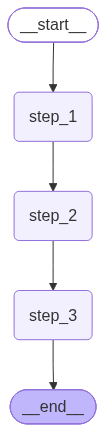

In [9]:
graph

In [10]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [11]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed

✅ Final State: {'input': 'start', 'step1': 'done', 'step2': 'done'}


In [17]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f183b13-1676-6ef1-8003-463dc2f34cef'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-07-19T20:34:08.650811+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f183b13-1674-6b9d-8002-3b57b29d2be6'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f183b13-1674-6b9d-8002-3b57b29d2be6'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-19T20:34:08.649896+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f183b11-c655-6e56-8001-0fc88d87bd7b'}}, tasks=(PregelTask(id='bbb3a272-8160-ad4f-e2d6-eb481117e3f